# 03. 검증 전략 (Validation Strategy) - Colab 버전

## 목적
Leave-One-Out 평가 전략 및 베이스라인 모델 성능 측정

## 핵심 구현
1. Leave-One-Out 평가 방법론
2. 베이스라인 모델 (Random, Frequency, Co-occurrence)
3. 평가 메트릭 (Hit@K, MRR)

## 입력
- `data/processed/recipe_v3/dataset_info.pt`
- `data/processed/recipe_v3/tokenizer.json`

## 출력
- `data/processed/recipe_v3/baseline_results.json`

In [2]:
# [1단계] Colab 환경 설정 및 Drive 마운트
import sys
import os

# Colab 환경 감지
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # 프로젝트 루트 설정 (본인의 Drive 경로에 맞게 수정)
    PROJECT_ROOT = '/content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone'
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, f'{PROJECT_ROOT}/notebooks')

    print(f"✅ Colab 환경 감지")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")
else:
    from pathlib import Path
    PROJECT_ROOT = Path().resolve().parent
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

    print("💻 로컬 환경에서 실행 중")
    print(f"📁 프로젝트 루트: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colab 환경 감지
📁 프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone


In [3]:
# [2단계] 라이브러리 임포트
import json
import random
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from tqdm.auto import tqdm

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Colab에서는 문자열을 Path로 변환
if IN_COLAB:
    PROJECT_ROOT = Path(PROJECT_ROOT)

from utils.gap_filling import IngredientTokenizer

print(f"프로젝트 루트: {PROJECT_ROOT}")

프로젝트 루트: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone


In [4]:
# 경로 설정 및 데이터 로드
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'recipe_v3'

# 토크나이저 로드
tokenizer = IngredientTokenizer.load(str(DATA_DIR / 'tokenizer.json'))
print(f"토크나이저 로드: vocab_size={tokenizer.vocab_size}")

# 데이터셋 로드
dataset_info = torch.load(DATA_DIR / 'dataset_info.pt')
train_recipes = dataset_info['train_recipes']
val_recipes = dataset_info['val_recipes']

print(f"학습 레시피: {len(train_recipes):,}")
print(f"검증 레시피: {len(val_recipes):,}")

토크나이저 로드: vocab_size=12089
학습 레시피: 181,937
검증 레시피: 20,216


## 1. Leave-One-Out 평가 프레임워크

In [5]:
class LeaveOneOutEvaluator:
    """Leave-One-Out 평가기

    각 레시피의 각 재료를 하나씩 제거하고
    나머지 재료로부터 제거된 재료를 예측
    """

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def evaluate(
        self,
        recipes: List[List[int]],
        predict_fn,
        k_values: List[int] = [1, 5, 10],
        max_samples: int = None,
        show_progress: bool = True
    ) -> Dict:
        """Leave-One-Out 평가

        Args:
            recipes: 인코딩된 레시피 리스트
            predict_fn: 예측 함수 (given_ids) -> top_k_ids
            k_values: 평가할 K 값들
            max_samples: 최대 샘플 수 (None=전체)

        Returns:
            메트릭 딕셔너리
        """
        max_k = max(k_values)
        hits = {k: 0 for k in k_values}
        reciprocal_ranks = []
        total_samples = 0

        # 샘플 생성
        samples = []
        for recipe_idx, recipe in enumerate(recipes):
            for ing_idx in range(len(recipe)):
                samples.append((recipe_idx, ing_idx))

        # 샘플 수 제한
        if max_samples and len(samples) > max_samples:
            samples = random.sample(samples, max_samples)

        iterator = tqdm(samples, desc="LOO 평가") if show_progress else samples

        for recipe_idx, ing_idx in iterator:
            recipe = recipes[recipe_idx]
            target_id = recipe[ing_idx]

            # 타겟 제외한 나머지 재료
            given_ids = [id_ for i, id_ in enumerate(recipe) if i != ing_idx]

            if len(given_ids) < 1:
                continue

            # 예측
            predictions = predict_fn(given_ids, max_k)

            # Hit@K 계산
            for k in k_values:
                if target_id in predictions[:k]:
                    hits[k] += 1

            # MRR 계산
            if target_id in predictions:
                rank = predictions.index(target_id) + 1
                reciprocal_ranks.append(1.0 / rank)
            else:
                reciprocal_ranks.append(0.0)

            total_samples += 1

        # 메트릭 계산
        metrics = {}
        for k in k_values:
            metrics[f'hit_at_{k}'] = hits[k] / total_samples * 100
        metrics['mrr'] = np.mean(reciprocal_ranks)
        metrics['total_samples'] = total_samples

        return metrics

In [6]:
# 평가기 초기화
evaluator = LeaveOneOutEvaluator(tokenizer)
print("Leave-One-Out 평가기 초기화 완료")

Leave-One-Out 평가기 초기화 완료


## 2. 베이스라인 모델 구현

In [7]:
class RandomBaseline:
    """랜덤 베이스라인: 무작위로 재료 추천"""

    def __init__(self, vocab_size: int, special_ids: List[int]):
        self.valid_ids = [
            i for i in range(vocab_size)
            if i not in special_ids
        ]

    def predict(self, given_ids: List[int], top_k: int) -> List[int]:
        """랜덤 예측 (주어진 재료 제외)"""
        candidates = [i for i in self.valid_ids if i not in given_ids]
        return random.sample(candidates, min(top_k, len(candidates)))

In [8]:
class FrequencyBaseline:
    """빈도 베이스라인: 가장 흔한 재료 추천"""

    def __init__(self, recipes: List[List[int]], special_ids: List[int]):
        # 빈도 계산
        counter = Counter()
        for recipe in recipes:
            counter.update(recipe)

        # 특수 토큰 제외하고 빈도순 정렬
        self.ranked_ids = [
            ing_id for ing_id, _ in counter.most_common()
            if ing_id not in special_ids
        ]

    def predict(self, given_ids: List[int], top_k: int) -> List[int]:
        """빈도 기반 예측 (주어진 재료 제외)"""
        predictions = []
        for ing_id in self.ranked_ids:
            if ing_id not in given_ids:
                predictions.append(ing_id)
                if len(predictions) >= top_k:
                    break
        return predictions

In [9]:
class CooccurrenceBaseline:
    """공출현 베이스라인: 주어진 재료와 자주 함께 등장하는 재료 추천"""

    def __init__(self, recipes: List[List[int]], special_ids: List[int]):
        # 공출현 행렬 구축
        self.cooccurrence = defaultdict(Counter)
        self.special_ids = set(special_ids)

        for recipe in tqdm(recipes, desc="공출현 계산"):
            valid_recipe = [i for i in recipe if i not in self.special_ids]
            for i, ing1 in enumerate(valid_recipe):
                for j, ing2 in enumerate(valid_recipe):
                    if i != j:
                        self.cooccurrence[ing1][ing2] += 1

        # 빈도 기반 폴백
        counter = Counter()
        for recipe in recipes:
            counter.update(recipe)
        self.fallback = [
            ing_id for ing_id, _ in counter.most_common()
            if ing_id not in self.special_ids
        ]

    def predict(self, given_ids: List[int], top_k: int) -> List[int]:
        """공출현 기반 예측"""
        # 주어진 재료들과의 공출현 점수 합산
        scores = Counter()
        for ing_id in given_ids:
            if ing_id in self.cooccurrence:
                scores.update(self.cooccurrence[ing_id])

        # 주어진 재료 및 특수 토큰 제외
        excluded = set(given_ids) | self.special_ids
        predictions = [
            ing_id for ing_id, _ in scores.most_common()
            if ing_id not in excluded
        ][:top_k]

        # 부족하면 빈도 기반으로 채움
        if len(predictions) < top_k:
            for ing_id in self.fallback:
                if ing_id not in excluded and ing_id not in predictions:
                    predictions.append(ing_id)
                    if len(predictions) >= top_k:
                        break

        return predictions

In [10]:
# 베이스라인 모델 초기화
special_ids = [tokenizer.PAD_ID, tokenizer.MASK_ID, tokenizer.UNK_ID,
               tokenizer.CLS_ID, tokenizer.SEP_ID]

print("베이스라인 모델 초기화...")

random_baseline = RandomBaseline(tokenizer.vocab_size, special_ids)
print("  - Random Baseline 완료")

freq_baseline = FrequencyBaseline(train_recipes, special_ids)
print("  - Frequency Baseline 완료")

cooc_baseline = CooccurrenceBaseline(train_recipes, special_ids)
print("  - Co-occurrence Baseline 완료")

베이스라인 모델 초기화...
  - Random Baseline 완료
  - Frequency Baseline 완료


공출현 계산:   0%|          | 0/181937 [00:00<?, ?it/s]

  - Co-occurrence Baseline 완료


## 3. 베이스라인 평가

In [11]:
# 평가 설정
K_VALUES = [1, 5, 10]
MAX_EVAL_SAMPLES = 10000  # 평가 샘플 수 제한 (속도)

print(f"평가 K 값: {K_VALUES}")
print(f"최대 평가 샘플: {MAX_EVAL_SAMPLES:,}")

평가 K 값: [1, 5, 10]
최대 평가 샘플: 10,000


In [12]:
# Random Baseline 평가
print("\n=== Random Baseline 평가 ===")
random_metrics = evaluator.evaluate(
    val_recipes,
    random_baseline.predict,
    k_values=K_VALUES,
    max_samples=MAX_EVAL_SAMPLES
)

print(f"Hit@1: {random_metrics['hit_at_1']:.2f}%")
print(f"Hit@5: {random_metrics['hit_at_5']:.2f}%")
print(f"Hit@10: {random_metrics['hit_at_10']:.2f}%")
print(f"MRR: {random_metrics['mrr']:.4f}")


=== Random Baseline 평가 ===


LOO 평가:   0%|          | 0/10000 [00:00<?, ?it/s]

Hit@1: 0.00%
Hit@5: 0.01%
Hit@10: 0.02%
MRR: 0.0001


In [13]:
# Frequency Baseline 평가
print("\n=== Frequency Baseline 평가 ===")
freq_metrics = evaluator.evaluate(
    val_recipes,
    freq_baseline.predict,
    k_values=K_VALUES,
    max_samples=MAX_EVAL_SAMPLES
)

print(f"Hit@1: {freq_metrics['hit_at_1']:.2f}%")
print(f"Hit@5: {freq_metrics['hit_at_5']:.2f}%")
print(f"Hit@10: {freq_metrics['hit_at_10']:.2f}%")
print(f"MRR: {freq_metrics['mrr']:.4f}")


=== Frequency Baseline 평가 ===


LOO 평가:   0%|          | 0/10000 [00:00<?, ?it/s]

Hit@1: 8.39%
Hit@5: 24.51%
Hit@10: 37.86%
MRR: 0.1567


In [14]:
# Co-occurrence Baseline 평가
print("\n=== Co-occurrence Baseline 평가 ===")
cooc_metrics = evaluator.evaluate(
    val_recipes,
    cooc_baseline.predict,
    k_values=K_VALUES,
    max_samples=MAX_EVAL_SAMPLES
)

print(f"Hit@1: {cooc_metrics['hit_at_1']:.2f}%")
print(f"Hit@5: {cooc_metrics['hit_at_5']:.2f}%")
print(f"Hit@10: {cooc_metrics['hit_at_10']:.2f}%")
print(f"MRR: {cooc_metrics['mrr']:.4f}")


=== Co-occurrence Baseline 평가 ===


LOO 평가:   0%|          | 0/10000 [00:00<?, ?it/s]

Hit@1: 10.64%
Hit@5: 28.79%
Hit@10: 40.58%
MRR: 0.1854


## 4. 결과 비교

In [15]:
# 결과 비교 테이블
import pandas as pd

results = {
    'Model': ['Random', 'Frequency', 'Co-occurrence'],
    'Hit@1': [
        random_metrics['hit_at_1'],
        freq_metrics['hit_at_1'],
        cooc_metrics['hit_at_1']
    ],
    'Hit@5': [
        random_metrics['hit_at_5'],
        freq_metrics['hit_at_5'],
        cooc_metrics['hit_at_5']
    ],
    'Hit@10': [
        random_metrics['hit_at_10'],
        freq_metrics['hit_at_10'],
        cooc_metrics['hit_at_10']
    ],
    'MRR': [
        random_metrics['mrr'],
        freq_metrics['mrr'],
        cooc_metrics['mrr']
    ]
}

df_results = pd.DataFrame(results)
print("\n=== 베이스라인 성능 비교 ===")
print(df_results.to_string(index=False))


=== 베이스라인 성능 비교 ===
        Model  Hit@1  Hit@5  Hit@10      MRR
       Random   0.00   0.01    0.02 0.000050
    Frequency   8.39  24.51   37.86 0.156668
Co-occurrence  10.64  28.79   40.58 0.185372


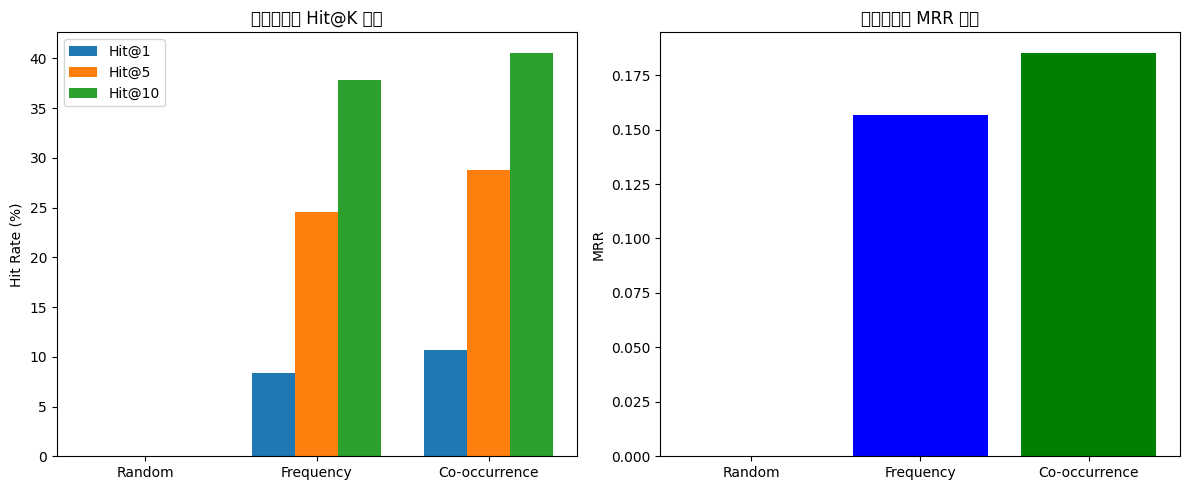

In [16]:
# 시각화
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hit@K 비교
x = np.arange(3)
width = 0.25

axes[0].bar(x - width, df_results['Hit@1'], width, label='Hit@1')
axes[0].bar(x, df_results['Hit@5'], width, label='Hit@5')
axes[0].bar(x + width, df_results['Hit@10'], width, label='Hit@10')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Model'])
axes[0].set_ylabel('Hit Rate (%)')
axes[0].set_title('베이스라인 Hit@K 비교')
axes[0].legend()

# MRR 비교
axes[1].bar(df_results['Model'], df_results['MRR'], color=['gray', 'blue', 'green'])
axes[1].set_ylabel('MRR')
axes[1].set_title('베이스라인 MRR 비교')

plt.tight_layout()
plt.savefig(DATA_DIR / 'baseline_comparison.png', dpi=150)
plt.show()

## 5. 목표 성능 설정

In [17]:
# 목표 성능
target_metrics = {
    'hit_at_1': 25.0,   # 25% 이상
    'hit_at_5': 50.0,   # 50% 이상 (핵심 목표)
    'hit_at_10': 65.0,  # 65% 이상
    'mrr': 0.35         # 0.35 이상
}

print("\n=== 목표 성능 ===")
print(f"Hit@1: {target_metrics['hit_at_1']:.1f}%")
print(f"Hit@5: {target_metrics['hit_at_5']:.1f}% (핵심 목표)")
print(f"Hit@10: {target_metrics['hit_at_10']:.1f}%")
print(f"MRR: {target_metrics['mrr']:.2f}")

# 현재 최고 성능 대비
best_hit5 = cooc_metrics['hit_at_5']
improvement_needed = target_metrics['hit_at_5'] - best_hit5
print(f"\n현재 최고 Hit@5: {best_hit5:.2f}%")
print(f"목표 달성을 위한 개선 필요: +{improvement_needed:.1f}%p")


=== 목표 성능 ===
Hit@1: 25.0%
Hit@5: 50.0% (핵심 목표)
Hit@10: 65.0%
MRR: 0.35

현재 최고 Hit@5: 28.79%
목표 달성을 위한 개선 필요: +21.2%p


## 6. 결과 저장

In [18]:
# 결과 저장
baseline_results = {
    'random': random_metrics,
    'frequency': freq_metrics,
    'cooccurrence': cooc_metrics,
    'target': target_metrics,
    'eval_samples': MAX_EVAL_SAMPLES,
    'k_values': K_VALUES
}

with open(DATA_DIR / 'baseline_results.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_results, f, ensure_ascii=False, indent=2)

print(f"베이스라인 결과 저장: {DATA_DIR / 'baseline_results.json'}")

베이스라인 결과 저장: /content/drive/MyDrive/Colab Notebooks/SSAFY_Class_18_Team_4_Final_Capstone/data/processed/recipe_v3/baseline_results.json


In [19]:
# 최종 요약
print("\n" + "="*50)
print("검증 전략 수립 완료")
print("="*50)
print("\n베이스라인 성능:")
print(f"  - Random: Hit@5 = {random_metrics['hit_at_5']:.2f}%")
print(f"  - Frequency: Hit@5 = {freq_metrics['hit_at_5']:.2f}%")
print(f"  - Co-occurrence: Hit@5 = {cooc_metrics['hit_at_5']:.2f}%")
print(f"\n목표:")
print(f"  - Hit@5 >= {target_metrics['hit_at_5']:.0f}%")
print(f"  - 개선 필요: +{improvement_needed:.1f}%p")
print(f"\n다음 단계: Masked Set Transformer 모델 학습")


검증 전략 수립 완료

베이스라인 성능:
  - Random: Hit@5 = 0.01%
  - Frequency: Hit@5 = 24.51%
  - Co-occurrence: Hit@5 = 28.79%

목표:
  - Hit@5 >= 50%
  - 개선 필요: +21.2%p

다음 단계: Masked Set Transformer 모델 학습
